
# Decision Tree Baseline — Incident Classification

This notebook trains and evaluates a **Decision Tree** for the fixed three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

It uses the same revised canonical dataset with two frozen evaluation settings:

1. **Grouped-random split**
2. **Spatial split (unseen stations)**

The primary model-selection metric is **validation Macro-F1**. The test set is evaluated only after the best hyperparameters have been selected.

> `all_zero_flow_window`, identifiers, station IDs, timestamps, and target-derived columns are retained only for auditing and are not used as predictors.


In [3]:

# Optional installation if a package is missing:
# !pip install pandas numpy scikit-learn matplotlib joblib

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]

# Change DATA_DIR only if the files are stored elsewhere.
DATA_DIR = Path(".")
CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")
OUTPUT_DIR = DATA_DIR / "decision_tree_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files "
            "or update DATA_DIR above."
        )

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /Users/andishahifahmuthahharah/Downloads/decision_tree_outputs



## 1. Load and validate the fixed data

The notebook verifies that:

- each `event_sample_id` is unique;
- manifests match the canonical dataset exactly;
- labels agree between the canonical file and each manifest;
- each sample belongs to one of `train`, `validation`, or `test`.


In [4]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)
print("\nClass distribution:")
display(canonical["target_class"].value_counts().reindex(CLASS_ORDER).to_frame("count"))

assert canonical["event_sample_id"].is_unique, "Duplicate event_sample_id in canonical dataset."
assert grouped_manifest["event_sample_id"].is_unique, "Duplicate event_sample_id in grouped manifest."
assert spatial_manifest["event_sample_id"].is_unique, "Duplicate event_sample_id in spatial manifest."
assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"]), "Grouped manifest mismatch."
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"]), "Spatial manifest mismatch."
assert set(canonical["target_class"].unique()) == set(CLASS_ORDER), "Unexpected target classes."
assert set(grouped_manifest["split"].unique()) == {"train", "validation", "test"}
assert set(spatial_manifest["split"].unique()) == {"train", "validation", "test"}

print("\nAll basic integrity checks passed.")


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)

Class distribution:


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179



All basic integrity checks passed.



## 2. Feature engineering

The raw seven-hour sequence is:

\[
[t-3,t-2,t-1,t_0,t+1,t+2,t+3].
\]

The Decision Tree receives only traffic-derived features:

- seven `log1p(flow)` values;
- six stabilized consecutive relative changes;
- first differences;
- pre-event and response means;
- mean shift and ratio;
- pre-event and response slopes;
- standard deviation, range, minimum, maximum;
- maximum drop and rise;
- cumulative post-onset change.

The relative change denominator is `max(abs(previous flow), 1)` to avoid division by zero. Values are clipped to `[-10, 10]` to prevent extreme ratios from dominating splits.


In [5]:

FLOW_COLS = [
    "flow_t_minus_3", "flow_t_minus_2", "flow_t_minus_1",
    "flow_t0", "flow_t_plus_1", "flow_t_plus_2", "flow_t_plus_3"
]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create leakage-safe traffic-only tabular features."""
    missing = [c for c in FLOW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing flow columns: {missing}")

    flow = df[FLOW_COLS].astype(float).to_numpy()
    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    X = pd.DataFrame(index=df.index)

    # Raw-scale compression
    for j, col in enumerate(FLOW_COLS):
        X[f"log1p_{col}"] = np.log1p(flow[:, j])

    # Consecutive first differences and stabilized relative changes
    diffs = np.diff(flow, axis=1)
    denom = np.maximum(np.abs(flow[:, :-1]), 1.0)
    rel = np.clip(diffs / denom, -10.0, 10.0)

    transition_names = ["m3_to_m2", "m2_to_m1", "m1_to_t0", "t0_to_p1", "p1_to_p2", "p2_to_p3"]
    for j, name in enumerate(transition_names):
        X[f"diff_{name}"] = diffs[:, j]
        X[f"rel_change_{name}"] = rel[:, j]

    pre = flow[:, :3]
    response = flow[:, 3:]

    X["pre_mean"] = pre.mean(axis=1)
    X["response_mean"] = response.mean(axis=1)
    X["mean_shift"] = X["response_mean"] - X["pre_mean"]
    X["response_pre_ratio"] = X["response_mean"] / np.maximum(X["pre_mean"], 1.0)

    X["onset_jump"] = flow[:, 3] - flow[:, 2]
    X["pre_slope"] = (flow[:, 2] - flow[:, 0]) / 2.0
    X["response_slope"] = (flow[:, 6] - flow[:, 3]) / 3.0

    X["window_mean"] = flow.mean(axis=1)
    X["window_std"] = flow.std(axis=1)
    X["window_min"] = flow.min(axis=1)
    X["window_max"] = flow.max(axis=1)
    X["window_range"] = X["window_max"] - X["window_min"]

    X["max_drop"] = np.minimum(diffs, 0).min(axis=1)
    X["max_rise"] = np.maximum(diffs, 0).max(axis=1)
    X["max_abs_change"] = np.abs(diffs).max(axis=1)
    X["cumulative_post_change"] = flow[:, 6] - flow[:, 3]

    if not np.isfinite(X.to_numpy()).all():
        raise ValueError("Engineered features contain NaN or infinite values.")
    return X

X_all = build_features(canonical)
y_all = canonical["target_class"].astype(str)

print("Feature matrix shape:", X_all.shape)
display(X_all.head())


Feature matrix shape: (5265, 35)


,log1p_flow_t_minus_3,log1p_flow_t_minus_2,log1p_flow_t_minus_1,log1p_flow_t0,log1p_flow_t_plus_1,log1p_flow_t_plus_2,log1p_flow_t_plus_3,diff_m3_to_m2,rel_change_m3_to_m2,diff_m2_to_m1,rel_change_m2_to_m1,diff_m1_to_t0,rel_change_m1_to_t0,diff_t0_to_p1,rel_change_t0_to_p1,diff_p1_to_p2,rel_change_p1_to_p2,diff_p2_to_p3,rel_change_p2_to_p3,pre_mean,response_mean,mean_shift,response_pre_ratio,onset_jump,pre_slope,response_slope,window_mean,window_std,window_min,window_max,window_range,max_drop,max_rise,max_abs_change,cumulative_post_change
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.639057,1.609438,2.639057,2.397895,2.833213,2.564949,2.079442,-9.0,-0.692308,9.0,2.25,-3.0,-0.230769,6.0,0.600000,-4.0,-0.250000,-5.0,-0.416667,10.000000,11.25,1.250000,1.125000,-3.0,0.0,-1.000000,10.714286,3.768830,4.0,16.0,12.0,-9.0,9.0,9.0,-3.0
3,0.000000,0.000000,3.465736,2.995732,3.433987,3.332205,0.000000,0.0,0.000000,31.0,10.00,-12.0,-0.387097,11.0,0.578947,-3.0,-0.100000,-27.0,-1.000000,10.333333,19.00,8.666667,1.838710,-12.0,15.5,-6.333333,15.285714,13.708332,0.0,31.0,31.0,-27.0,31.0,31.0,-19.0
4,3.091042,3.433987,3.526361,3.555348,4.304065,4.663439,5.081404,9.0,0.428571,3.0,0.10,1.0,0.030303,39.0,1.147059,32.0,0.438356,55.0,0.523810,28.000000,93.00,65.000000,3.321429,1.0,6.0,42.000000,65.142857,47.561775,21.0,160.0,139.0,0.0,55.0,55.0,126.0



## 3. Model selection and evaluation functions

A compact, pre-declared hyperparameter grid is evaluated on the validation set. Selection uses:

1. highest validation Macro-F1;
2. highest validation balanced accuracy as a tie-breaker;
3. shallower tree as the final tie-breaker.

The test set is not used during selection.


In [6]:

PARAM_GRID = [
    {"max_depth": d, "min_samples_leaf": leaf, "min_samples_split": split, "ccp_alpha": alpha}
    for d in [3, 5, 7, 10, None]
    for leaf in [5, 10, 20, 40]
    for split in [10, 20]
    for alpha in [0.0, 0.0005, 0.001]
]


def merge_split(canonical_df: pd.DataFrame, manifest: pd.DataFrame) -> pd.DataFrame:
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()
    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )
    assert len(merged) == len(canonical_df)
    assert (merged["target_class"] == merged["target_class_manifest"]).all(), "Target mismatch after merge."
    return merged.drop(columns="target_class_manifest")


def metric_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def run_decision_tree_experiment(split_name: str, manifest: pd.DataFrame):
    data = merge_split(canonical, manifest)
    X = build_features(data)
    y = data["target_class"].astype(str)

    masks = {part: data["split"].eq(part).to_numpy() for part in ["train", "validation", "test"]}
    X_train, y_train = X.loc[masks["train"]], y.loc[masks["train"]]
    X_val, y_val = X.loc[masks["validation"]], y.loc[masks["validation"]]
    X_test, y_test = X.loc[masks["test"]], y.loc[masks["test"]]

    print(f"\n=== {split_name} ===")
    print("Train / validation / test:", len(y_train), len(y_val), len(y_test))
    split_counts = pd.crosstab(data["split"], data["target_class"]).reindex(
        index=["train", "validation", "test"], columns=CLASS_ORDER, fill_value=0
    )
    display(split_counts)

    search_rows = []
    models = []
    for params in PARAM_GRID:
        model = DecisionTreeClassifier(
            criterion="gini",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            **params,
        )
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        metrics = metric_row(y_val, val_pred)
        search_rows.append({**params, **metrics, "tree_depth": model.get_depth(), "n_leaves": model.get_n_leaves()})
        models.append(model)

    search_df = pd.DataFrame(search_rows)
    # None cannot be sorted directly with integers; use actual fitted depth as complexity tie-breaker.
    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "tree_depth", "n_leaves"],
        ascending=[False, False, True, True],
    )
    best_idx = ranking.index[0]
    best_model = models[best_idx]
    best_params = PARAM_GRID[best_idx]

    print("Best validation parameters:", best_params)
    display(ranking.head(10).reset_index(drop=True))

    partition_results = []
    predictions = []
    for part, X_part, y_part in [
        ("train", X_train, y_train),
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        pred = best_model.predict(X_part)
        partition_results.append({"split_scheme": split_name, "partition": part, **metric_row(y_part, pred)})
        ids = data.loc[masks[part], "event_sample_id"].to_numpy()
        predictions.append(pd.DataFrame({
            "event_sample_id": ids,
            "split_scheme": split_name,
            "partition": part,
            "y_true": y_part.to_numpy(),
            "y_pred": pred,
        }))

    results_df = pd.DataFrame(partition_results)
    prediction_df = pd.concat(predictions, ignore_index=True)
    test_pred = prediction_df.loc[prediction_df["partition"].eq("test"), "y_pred"]

    print("\nOverall metrics:")
    display(results_df)
    print("\nTest classification report:")
    report = classification_report(
        y_test,
        test_pred,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    display(report_df)

    # Save tables and model
    safe_name = split_name.lower().replace("-", "_").replace(" ", "_")
    search_df.to_csv(OUTPUT_DIR / f"{safe_name}_hyperparameter_search.csv", index=False)
    results_df.to_csv(OUTPUT_DIR / f"{safe_name}_metrics.csv", index=False)
    report_df.to_csv(OUTPUT_DIR / f"{safe_name}_test_classification_report.csv")
    prediction_df.to_csv(OUTPUT_DIR / f"{safe_name}_predictions.csv", index=False)
    joblib.dump(best_model, OUTPUT_DIR / f"{safe_name}_decision_tree.joblib")

    with open(OUTPUT_DIR / f"{safe_name}_best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_pred,
        labels=CLASS_ORDER,
        display_labels=CLASS_ORDER,
        cmap=None,
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"Decision Tree — {split_name} test confusion matrix")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{safe_name}_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.show()

    # Feature importance
    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    importance_df.to_csv(OUTPUT_DIR / f"{safe_name}_feature_importance.csv", index=False)
    display(importance_df.head(20))

    top = importance_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["feature"], top["importance"])
    ax.set_title(f"Decision Tree — {split_name} feature importance")
    ax.set_xlabel("Gini importance")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{safe_name}_feature_importance.png", dpi=180, bbox_inches="tight")
    plt.show()

    # Limited tree visualization for readability
    fig, ax = plt.subplots(figsize=(24, 10))
    plot_tree(
        best_model,
        feature_names=X.columns,
        class_names=best_model.classes_,
        filled=False,
        rounded=True,
        max_depth=3,
        fontsize=7,
        ax=ax,
    )
    ax.set_title(f"Decision Tree — {split_name} (first 3 levels)")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{safe_name}_tree_top_levels.png", dpi=180, bbox_inches="tight")
    plt.show()

    return {
        "model": best_model,
        "best_params": best_params,
        "metrics": results_df,
        "report": report_df,
        "predictions": prediction_df,
        "importance": importance_df,
        "search": search_df,
    }



## 4. Grouped-random experiment

Samples belonging to the same temporal overlap group remain in the same partition. Stations may still be represented across partitions.



=== Grouped-random ===
Train / validation / test: 3685 784 796


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2510,352,823
validation,530,79,175
test,541,74,181


Best validation parameters: {'max_depth': None, 'min_samples_leaf': 40, 'min_samples_split': 10, 'ccp_alpha': 0.0}


,max_depth,min_samples_leaf,min_samples_split,ccp_alpha,accuracy,balanced_accuracy,macro_f1,weighted_f1,tree_depth,n_leaves
0,NaN,40,10,0.0000,0.322704,0.361155,0.292509,0.347478,14,57
1,NaN,40,20,0.0000,0.322704,0.361155,0.292509,0.347478,14,57
2,NaN,40,10,0.0005,0.320153,0.359897,0.290635,0.344224,14,56
3,NaN,40,20,0.0005,0.320153,0.359897,0.290635,0.344224,14,56
4,NaN,40,10,0.0010,0.317602,0.347156,0.286144,0.347094,13,44
5,NaN,40,20,0.0010,0.317602,0.347156,0.286144,0.347094,13,44
6,NaN,10,10,0.0000,0.349490,0.317953,0.283521,0.383281,27,217
7,NaN,10,20,0.0000,0.349490,0.317953,0.283521,0.383281,27,217
8,NaN,5,10,0.0000,0.358418,0.294999,0.277075,0.397763,33,381
9,NaN,10,10,0.0005,0.336735,0.315491,0.276031,0.367766,26,184



Overall metrics:


,split_scheme,partition,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,train,0.424423,0.518037,0.400152,0.447063
1,Grouped-random,validation,0.322704,0.361155,0.292509,0.347478
2,Grouped-random,test,0.335427,0.377126,0.303284,0.362033



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.688073,0.277264,0.395257,541.000000
ACCIDENT,0.117117,0.351351,0.175676,74.000000
OTHER_DISRUPTION,0.255618,0.502762,0.338920,181.000000
accuracy,0.335427,0.335427,0.335427,0.335427
macro avg,0.353603,0.377126,0.303284,796.000000
weighted avg,0.536660,0.335427,0.362033,796.000000


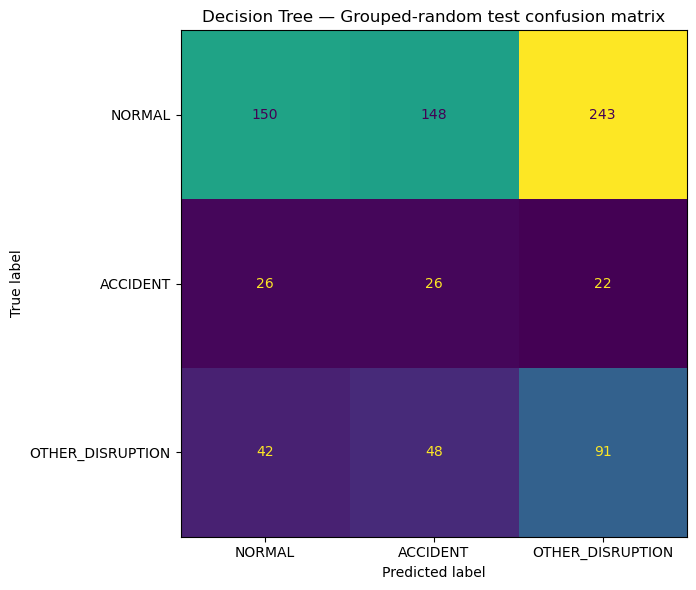

,feature,importance
15,diff_p1_to_p2,0.108949
22,response_pre_ratio,0.095294
34,cumulative_post_change,0.083878
0,log1p_flow_t_minus_3,0.077831
26,window_mean,0.075398
4,log1p_flow_t_plus_1,0.064369
16,rel_change_p1_to_p2,0.051433
32,max_rise,0.048892
8,rel_change_m3_to_m2,0.037072
2,log1p_flow_t_minus_1,0.032459


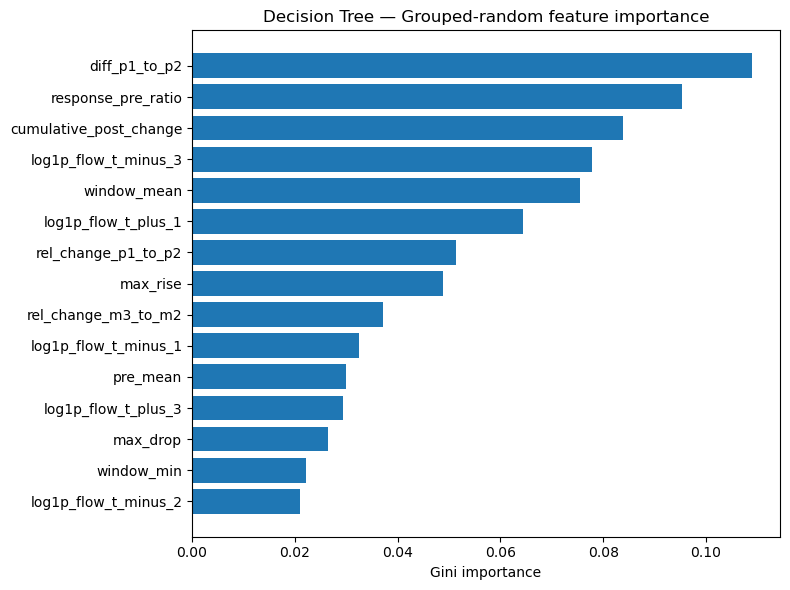

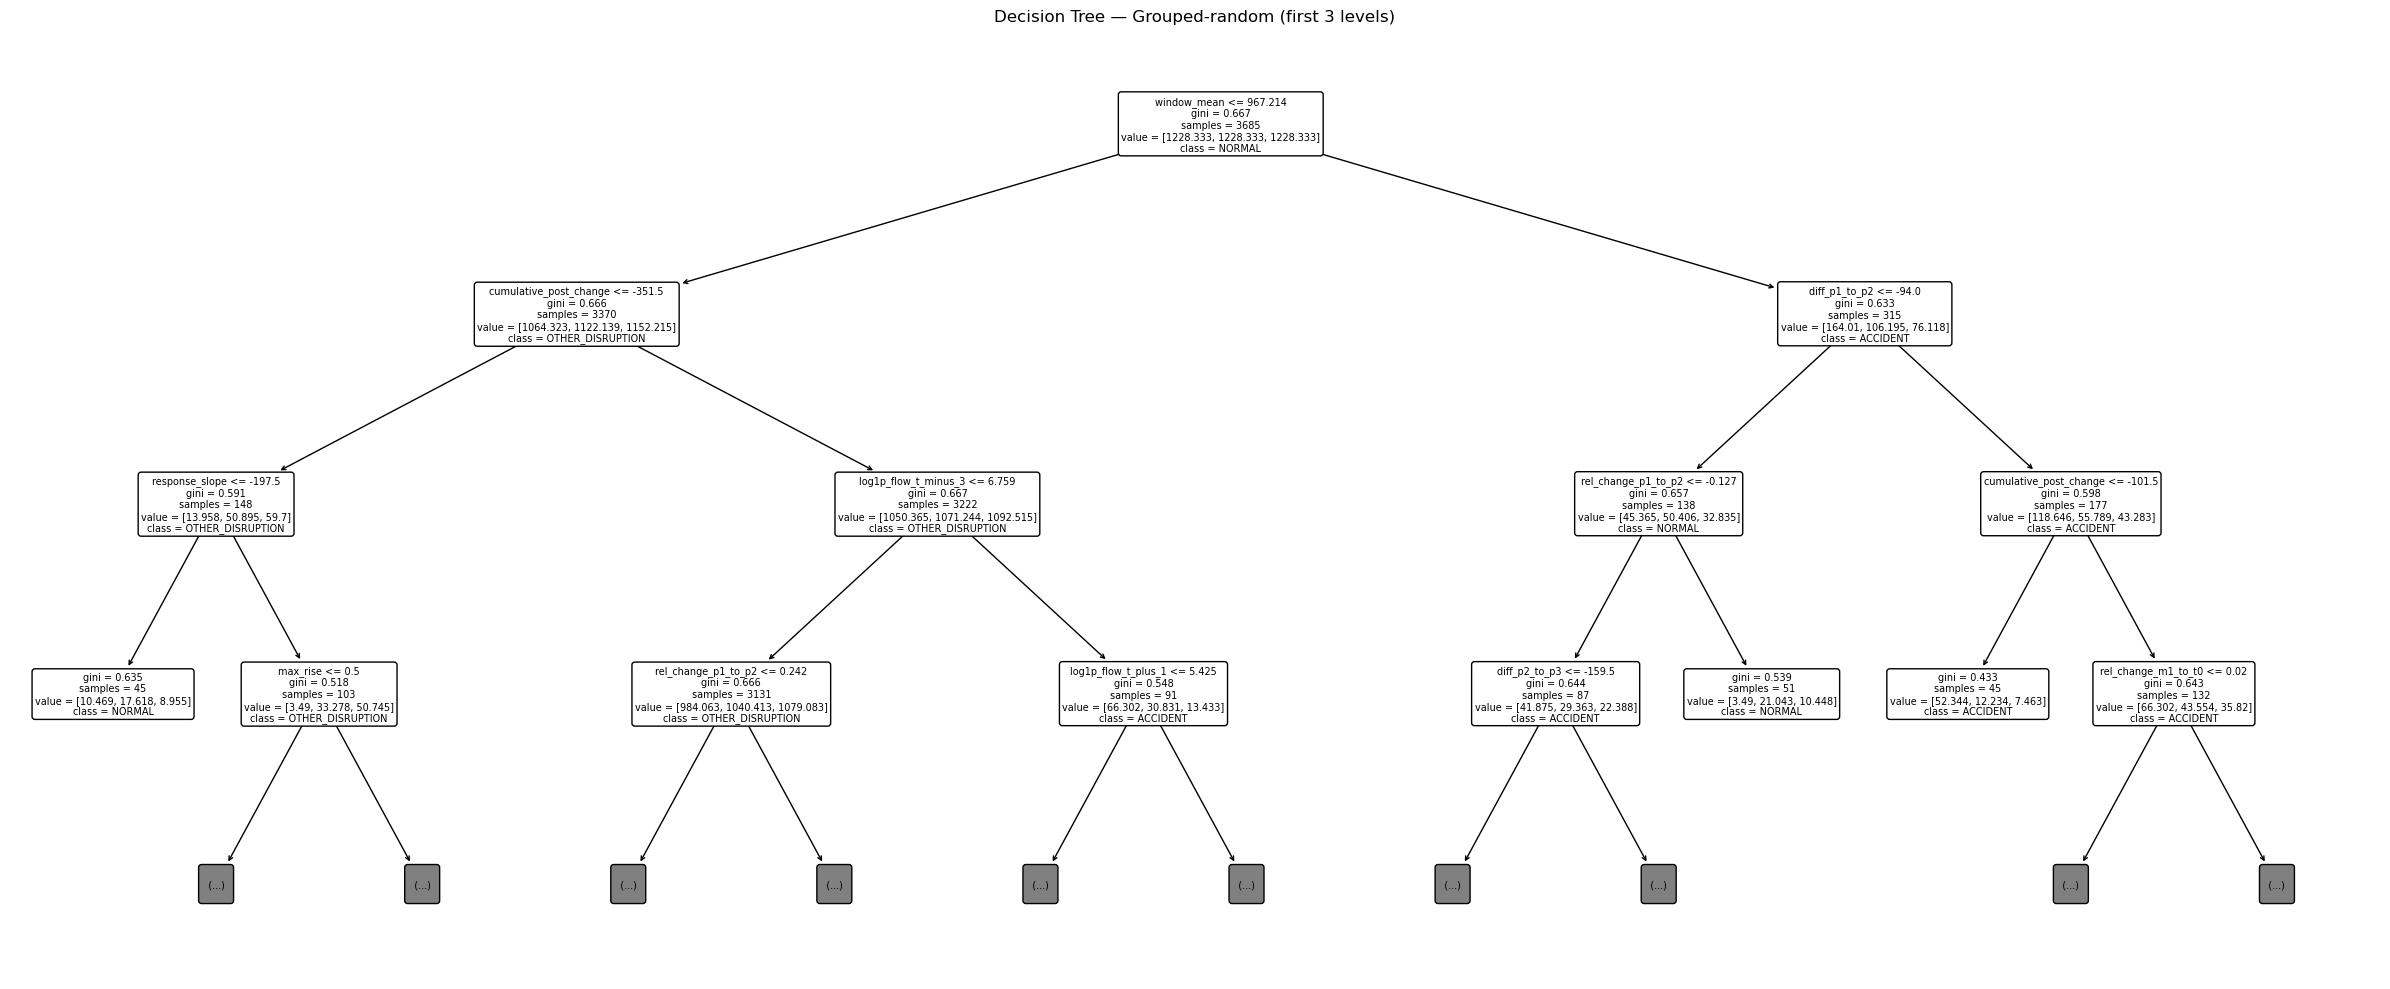

In [7]:

grouped_results = run_decision_tree_experiment(
    split_name="Grouped-random",
    manifest=grouped_manifest,
)



## 5. Spatial holdout experiment

Stations assigned to validation or test are unseen during training. This is the stricter test of transfer to new sensor locations.



=== Spatial holdout ===
Train / validation / test: 3703 806 756


target_class,NORMAL,ACCIDENT,OTHER_DISRUPTION
split,,,
train,2517,347,839
validation,549,84,173
test,515,74,167


Best validation parameters: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 10, 'ccp_alpha': 0.0}


,max_depth,min_samples_leaf,min_samples_split,ccp_alpha,accuracy,balanced_accuracy,macro_f1,weighted_f1,tree_depth,n_leaves
0,NaN,5,10,0.0000,0.369727,0.344365,0.308155,0.407774,22,408
1,NaN,10,10,0.0000,0.358561,0.346220,0.303968,0.392882,21,229
2,NaN,10,20,0.0000,0.358561,0.346220,0.303968,0.392882,21,229
3,NaN,10,10,0.0005,0.344913,0.344820,0.296519,0.376758,20,195
4,NaN,10,20,0.0005,0.344913,0.344820,0.296519,0.376758,20,195
5,NaN,5,10,0.0005,0.349876,0.331289,0.293716,0.386047,22,293
6,NaN,5,20,0.0000,0.339950,0.334349,0.289139,0.372543,20,257
7,10.0,10,10,0.0000,0.326303,0.354187,0.287331,0.347987,10,138
8,10.0,10,20,0.0000,0.326303,0.354187,0.287331,0.347987,10,138
9,NaN,5,20,0.0005,0.336228,0.332528,0.286639,0.368186,20,227



Overall metrics:


,split_scheme,partition,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Spatial holdout,train,0.664326,0.750763,0.635947,0.680666
1,Spatial holdout,validation,0.369727,0.344365,0.308155,0.407774
2,Spatial holdout,test,0.337302,0.306479,0.253191,0.357216



Test classification report:


,precision,recall,f1-score,support
NORMAL,0.697248,0.295146,0.414734,515.000000
ACCIDENT,0.010870,0.013514,0.012048,74.000000
OTHER_DISRUPTION,0.228700,0.610778,0.332790,167.000000
accuracy,0.337302,0.337302,0.337302,0.337302
macro avg,0.312272,0.306479,0.253191,756.000000
weighted avg,0.526561,0.337302,0.357216,756.000000


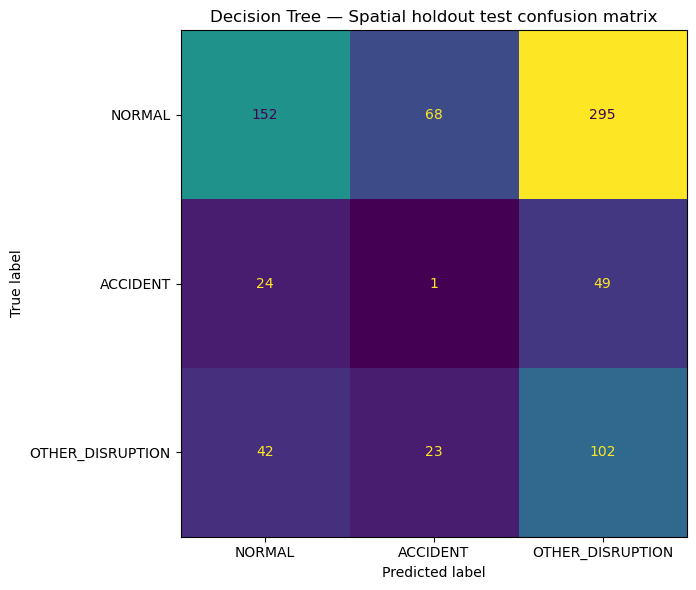

,feature,importance
8,rel_change_m3_to_m2,0.082625
18,rel_change_p2_to_p3,0.074046
10,rel_change_m2_to_m1,0.073498
12,rel_change_m1_to_t0,0.043377
7,diff_m3_to_m2,0.043088
16,rel_change_p1_to_p2,0.040333
22,response_pre_ratio,0.036019
21,mean_shift,0.035470
32,max_rise,0.035405
33,max_abs_change,0.032592


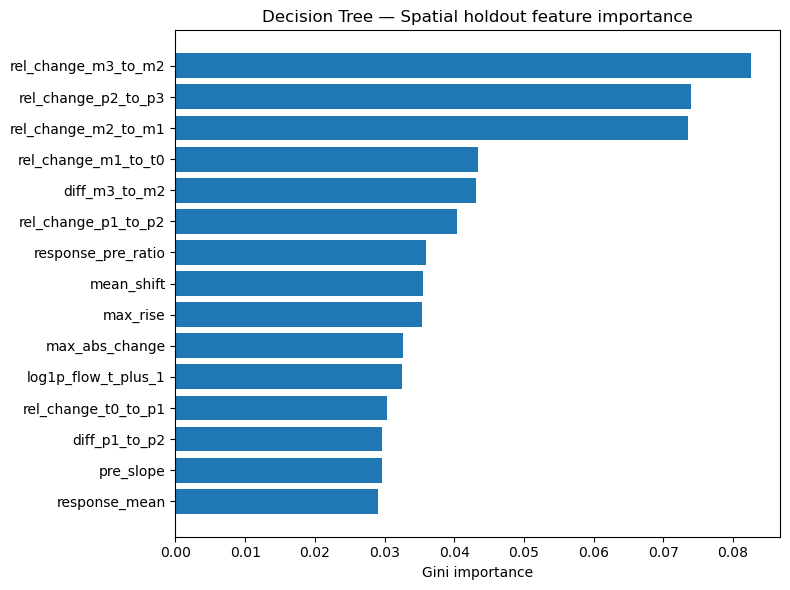

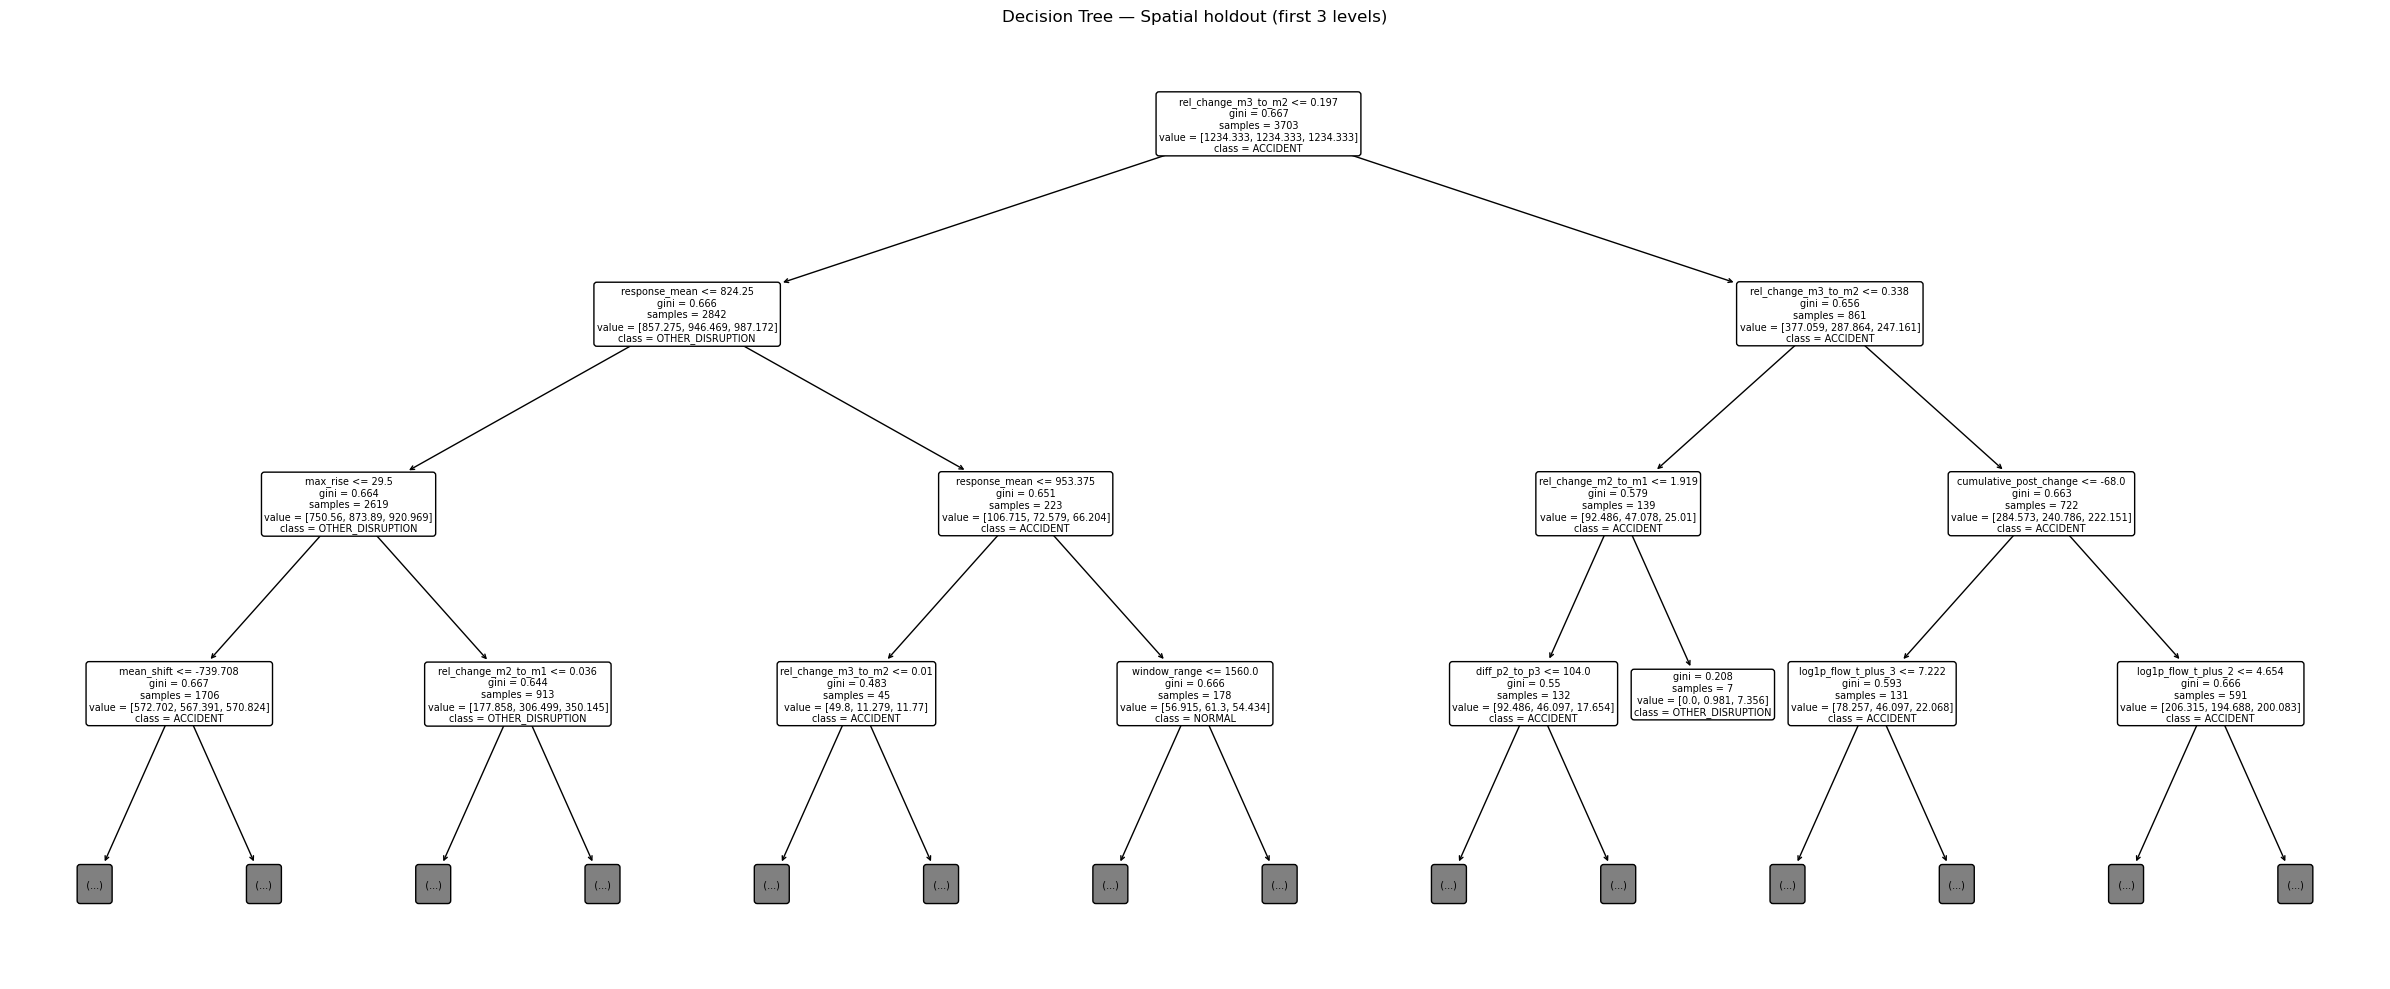

In [8]:

spatial_results = run_decision_tree_experiment(
    split_name="Spatial holdout",
    manifest=spatial_manifest,
)



## 6. Final comparison

Macro-F1 is the primary metric. Accuracy is reported but should not be used alone because `NORMAL` is the majority class.


In [9]:

comparison = pd.concat(
    [grouped_results["metrics"], spatial_results["metrics"]],
    ignore_index=True,
)
comparison.to_csv(OUTPUT_DIR / "decision_tree_all_metrics.csv", index=False)

test_comparison = comparison[comparison["partition"].eq("test")].reset_index(drop=True)
print("Test-set comparison:")
display(test_comparison)

print("\nSaved files:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print("-", p.name)


Test-set comparison:


,split_scheme,partition,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Grouped-random,test,0.335427,0.377126,0.303284,0.362033
1,Spatial holdout,test,0.337302,0.306479,0.253191,0.357216



Saved files:
- decision_tree_all_metrics.csv
- grouped_random_best_params.json
- grouped_random_confusion_matrix.png
- grouped_random_decision_tree.joblib
- grouped_random_feature_importance.csv
- grouped_random_feature_importance.png
- grouped_random_hyperparameter_search.csv
- grouped_random_metrics.csv
- grouped_random_predictions.csv
- grouped_random_test_classification_report.csv
- grouped_random_tree_top_levels.png
- spatial_holdout_best_params.json
- spatial_holdout_confusion_matrix.png
- spatial_holdout_decision_tree.joblib
- spatial_holdout_feature_importance.csv
- spatial_holdout_feature_importance.png
- spatial_holdout_hyperparameter_search.csv
- spatial_holdout_metrics.csv
- spatial_holdout_predictions.csv
- spatial_holdout_test_classification_report.csv
- spatial_holdout_tree_top_levels.png



## Interpretation guidance

Focus on:

- test **Macro-F1** and balanced accuracy;
- recall for `ACCIDENT` and `OTHER_DISRUPTION`;
- the confusion matrix, especially `NORMAL → OTHER_DISRUPTION` and `ACCIDENT ↔ OTHER_DISRUPTION`;
- the gap between grouped-random and spatial holdout performance;
- whether traffic-only features can identify incident type despite hourly aggregation, all-zero windows, and heterogeneous disruption patterns.

The Decision Tree is a transparent baseline. It does not require early stopping; overfitting is controlled through depth, leaf-size, split-size, and cost-complexity pruning selected on the validation set.
